1. Import required libraries

In [70]:
import numpy as np
import PIL.Image as image
import matplotlib.pyplot as plt

2. Define manual erosion and dilation functions

In [71]:
def erosion(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    result = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            window = padded[i:i+kh, j:j+kw]
            if np.all(window[kernel == 1] == 1):
                result[i, j] = 1
    return result

def dilation(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    result = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            window = padded[i:i+kh, j:j+kw]
            if np.any(window[kernel == 1] == 1):
                result[i, j] = 1
    return result

3. Load the fingerprint image

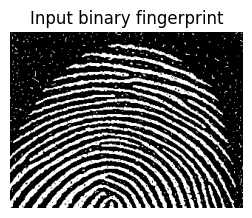

In [73]:
img = image.open("Images/hand_image.jpg").convert('L')
img_array = np.array(img)

binary_img = np.where(img_array > 127, 1, 0)

plt.figure(figsize=(3, 3))
plt.imshow(binary_img, cmap='gray')
plt.title("Input binary fingerprint")
plt.axis('off')
plt.show()

4. Define structuring element B (3×3 ones)

In [74]:
B = np.ones((3, 3), dtype=np.uint8)

Step 1 – Erosion

In [75]:
A1 = erosion(binary_img, B)

Step 2 – Dilation (completes opening)

In [76]:
A2 = dilation(A1, B)

Step 3 – Another dilation

In [77]:
A3 = dilation(A2, B)

Step 4 – Final erosion (closing of the opened image)

In [78]:
A4 = erosion(A3, B)

Step 5 – Morphological boundary extraction

In [79]:
A4_eroded = erosion(A4, B)
A5 = A4 - A4_eroded

6. Display all intermediate and final results

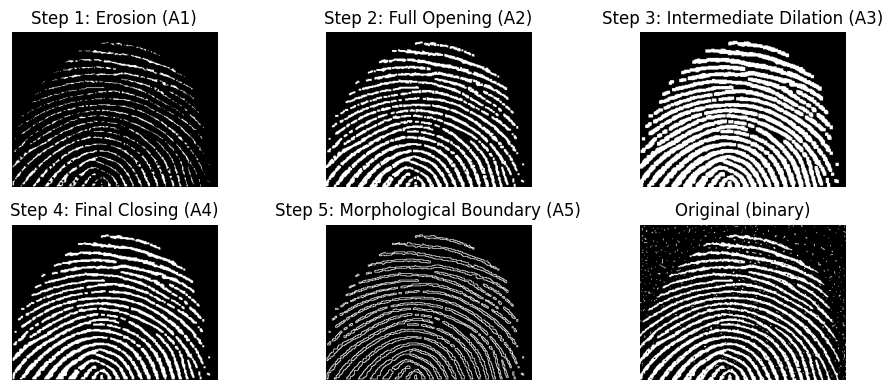

In [80]:
titles = [
    "Step 1: Erosion (A1)",
    "Step 2: Full Opening (A2)",
    "Step 3: Intermediate Dilation (A3)",
    "Step 4: Final Closing (A4)",
    "Step 5: Morphological Boundary (A5)"
]
images = [A1, A2, A3, A4, A5]

plt.figure(figsize=(10, 4))
for i, (im, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 3, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(binary_img, cmap='gray')
plt.title("Original (binary)")
plt.axis('off')

plt.tight_layout()
plt.show()